# Dataset & fold sanity checks: age and sex

Goal: verify whether your **patient-wise, (label × dataset)-stratified folds** preserve the **age** and **sex** distributions.

We’ll do this in three layers:
1. **Overall dataset structure** (rows, sources, label balance, missingness).
2. **Per-fold structure** (counts and label balance by source).
3. **Age/Sex drift checks**: compare each fold vs the overall distribution **within each source** and **within each (source, chagas)** stratum.

Notes:
- Some sources are **uni-labeled** (e.g. PTB-XL all `chagas=0`, SaMi-Trop all `chagas=1`). That’s expected; we still want them spread evenly across folds.
- We treat PTB-XL “HIPAA-masked” ages (`>=300`) as age `90` for visualization.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except Exception:
    def display(*args, **kwargs):
        return None

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    pass

# --- Configure metadata path ---
# You can also set an env var: META_PATH=/path/to/metadata.csv
META_PATH = Path(os.environ.get(
    'META_PATH',
    '/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/metadata.csv'
))

if not META_PATH.is_file():
    raise FileNotFoundError(
        f"Metadata CSV not found: {META_PATH}. "
        "Set META_PATH env var or update META_PATH in this notebook."
    )

df = pd.read_csv(META_PATH, low_memory=False)

required = {'exam_id', 'age', 'sex', 'chagas', 'source', 'fold'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in metadata: {sorted(missing)}")

# --- Clean/normalize columns ---
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# PTB-XL HIPAA mask: ages > 89 may appear as 300+.
# We cap them to 90 for visualization/grouping.
df.loc[df['age'] >= 300, 'age'] = 90

# Normalize sex into {Male, Female, Unknown}
# - CODE-15 / SaMi-Trop: is_male True/False
# - PTB-XL: sex 0/1 (0=male, 1=female)
# - Some rows may already be strings 'Male'/'Female'

def normalize_sex(val):
    if pd.isna(val):
        return 'Unknown'
    if isinstance(val, bool):
        return 'Male' if val else 'Female'
    if isinstance(val, (int, float, np.integer, np.floating)):
        if val == 0:
            return 'Male'
        if val == 1:
            return 'Female'
        return 'Unknown'
    if isinstance(val, str):
        v = val.strip().lower()
        if v.startswith('m'):
            return 'Male'
        if v.startswith('f'):
            return 'Female'
    return 'Unknown'

df['sex_norm'] = df['sex'].apply(normalize_sex)

# Make sure fold is integer-ish
if not np.issubdtype(df['fold'].dtype, np.number):
    df['fold'] = pd.to_numeric(df['fold'], errors='coerce')

df['fold'] = df['fold'].astype('Int64')

print('Rows:', len(df))
print('Sources:', df['source'].nunique())
print('Folds:', df['fold'].nunique())

df.head()

Rows: 366185
Sources: 3
Folds: 5


,exam_id,age,sex,chagas,source,path,resample_method,patient_id,fold,proc_stem,processed_root,sex_norm
0,1103441,50,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,NaN,1103441,1,1103441,/home/flo178/projects/master-thesis/datasets/p...,Female
1,392056,24,Male,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,NaN,392056,1,392056,/home/flo178/projects/master-thesis/datasets/p...,Male
2,411968,72,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,NaN,411968,0,411968,/home/flo178/projects/master-thesis/datasets/p...,Female
3,956206,63,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,NaN,956206,3,956206,/home/flo178/projects/master-thesis/datasets/p...,Female
4,2848422,69,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,NaN,2848422,2,2848422,/home/flo178/projects/master-thesis/datasets/p...,Female


## CODE-15 label coverage check

This checks whether `code15_chagas_labels.csv` contains duplicate `exam_id`s and whether all labeled exams were exported/processed into the WFDB tree (i.e., appear in `metadata.csv`).


In [2]:
# --- CODE-15 label coverage check ---
# Expected location: <physionet_root>/code15/code15_chagas_labels.csv

physionet_root = META_PATH.parent.parent  # .../physionet2025
labels_path = physionet_root / 'code15' / 'code15_chagas_labels.csv'
print('Looking for:', labels_path)

if not labels_path.is_file():
    print('Missing labels CSV. Update labels_path if your folder differs.')
else:
    lab = pd.read_csv(labels_path)
    if 'exam_id' not in lab.columns:
        raise ValueError(f"Expected 'exam_id' column in {labels_path}, got: {list(lab.columns)}")

    n_rows = len(lab)
    n_unique = lab['exam_id'].nunique(dropna=True)
    n_dupes = n_rows - n_unique

    print('labels rows:', n_rows)
    print('unique exam_id:', n_unique)
    print('duplicate rows:', n_dupes)

    # Compare to metadata
    code_meta = df[df['source'].astype(str).isin({'CODE-15%', 'CODE-15'})].copy()
    meta_exam_ids = set(code_meta['exam_id'].astype(str))
    label_exam_ids = set(lab['exam_id'].astype(str))

    missing_in_meta = sorted(label_exam_ids - meta_exam_ids)
    extra_in_meta = sorted(meta_exam_ids - label_exam_ids)

    print('CODE-15 exams in metadata:', len(meta_exam_ids))
    print('CODE-15 labeled exam_ids:', len(label_exam_ids))
    print('labeled but missing in metadata:', len(missing_in_meta))
    print('in metadata but not in labels:', len(extra_in_meta))

    if missing_in_meta:
        print('Example missing exam_ids:', missing_in_meta[:10])

    if extra_in_meta:
        print('Example extra exam_ids:', extra_in_meta[:10])

Looking for: /home/flo178/projects/master-thesis/datasets/physionet2025/code15/code15_chagas_labels.csv
labels rows: 343424
unique exam_id: 343424
duplicate rows: 0
CODE-15 exams in metadata: 342755
CODE-15 labeled exam_ids: 343424
labeled but missing in metadata: 669
in metadata but not in labels: 0
Example missing exam_ids: ['1006606', '1012984', '1015802', '102019', '1023545', '1024570', '1026433', '1027242', '1032169', '1042196']


## 1) Overall dataset structure

We start by checking:
- sample counts by `source` and `chagas`
- missingness in `age` / `sex_norm`

In [3]:
# Counts by source × label
counts = (
    df.groupby(['source', 'chagas'])['exam_id']
      .count()
      .rename('n')
      .reset_index()
)

display(counts.sort_values(['source', 'chagas']))

# Pivot for quick view
pivot_counts = counts.pivot_table(index='source', columns='chagas', values='n', fill_value=0)
display(pivot_counts)

# Missingness
missingness = pd.DataFrame({
    'n_rows': df.groupby('source').size(),
    'age_missing_frac': df.groupby('source')['age'].apply(lambda s: s.isna().mean()),
    'sex_unknown_frac': df.groupby('source')['sex_norm'].apply(lambda s: (s=='Unknown').mean()),
})

display(missingness)

,source,chagas,n
0,CODE-15%,0,336196
1,CODE-15%,1,6559
2,PTB-XL,0,21799
3,SaMi-Trop,1,1631


chagas,0,1
source,,
CODE-15%,336196.0,6559.0
PTB-XL,21799.0,0.0
SaMi-Trop,0.0,1631.0


,n_rows,age_missing_frac,sex_unknown_frac
source,,,
CODE-15%,342755,0.0,0.0
PTB-XL,21799,0.0,0.0
SaMi-Trop,1631,0.0,0.0


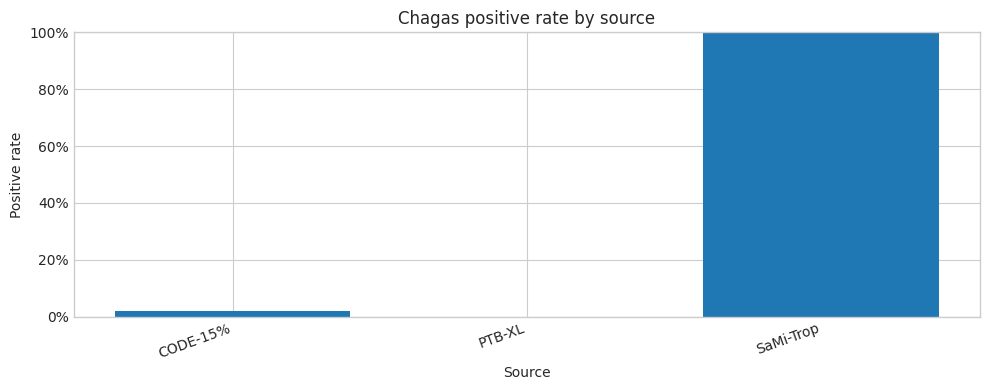

/tmp/ipykernel_10918/998096611.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


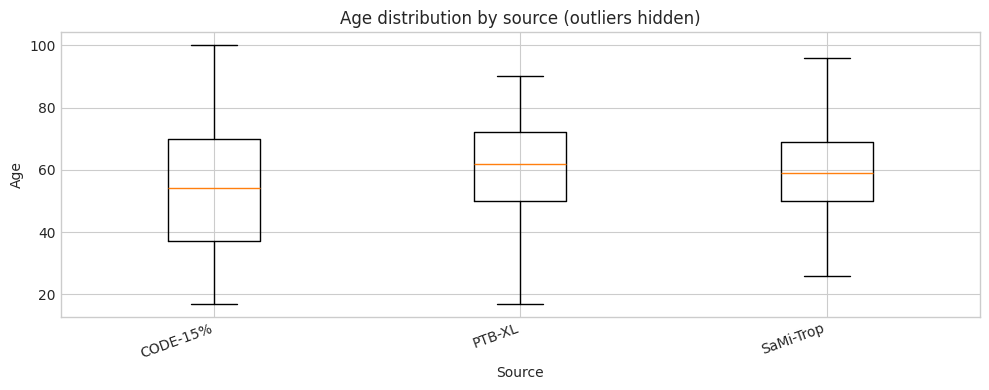

In [4]:
# Plot: label balance per source
src_order = sorted(df['source'].dropna().unique())

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# compute positive rate per source
pos_rate = (
    df.groupby('source')['chagas']
      .mean()
      .reindex(src_order)
)

ax.bar(src_order, pos_rate.values)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Chagas positive rate by source')
ax.set_xlabel('Source')
ax.set_ylabel('Positive rate')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Plot: age distribution by source (boxplot)
age_df = df[df['age'].notna()].copy()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.boxplot(
    [age_df.loc[age_df.source == s, 'age'].values for s in src_order],
    labels=src_order,
    showfliers=False,
)
ax.set_title('Age distribution by source (outliers hidden)')
ax.set_xlabel('Source')
ax.set_ylabel('Age')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 2) Fold structure (counts and label balance)

Because we split with stratification on `(chagas, source)` and group by `patient_id`, we expect:
- each `source` to be spread across folds
- within CODE-15, the `chagas` prevalence to be very similar across folds

In [5]:
# Count per fold × source
fold_source_counts = df.groupby(['fold', 'source']).size().rename('n').reset_index()
display(fold_source_counts.pivot_table(index='fold', columns='source', values='n', fill_value=0))

# Chagas prevalence per fold × source
fold_source_pos = (
    df.groupby(['fold', 'source'])['chagas']
      .mean()
      .rename('pos_rate')
      .reset_index()
)
display(fold_source_pos.pivot_table(index='fold', columns='source', values='pos_rate'))

source,CODE-15%,PTB-XL,SaMi-Trop
fold,,,
0,68521.0,4371.0,345.0
1,68607.0,4289.0,341.0
2,68505.0,4393.0,340.0
3,68530.0,4414.0,293.0
4,68592.0,4332.0,312.0


source,CODE-15%,PTB-XL,SaMi-Trop
fold,,,
0,0.018753,0.0,1.0
1,0.018774,0.0,1.0
2,0.019473,0.0,1.0
3,0.019451,0.0,1.0
4,0.019230,0.0,1.0


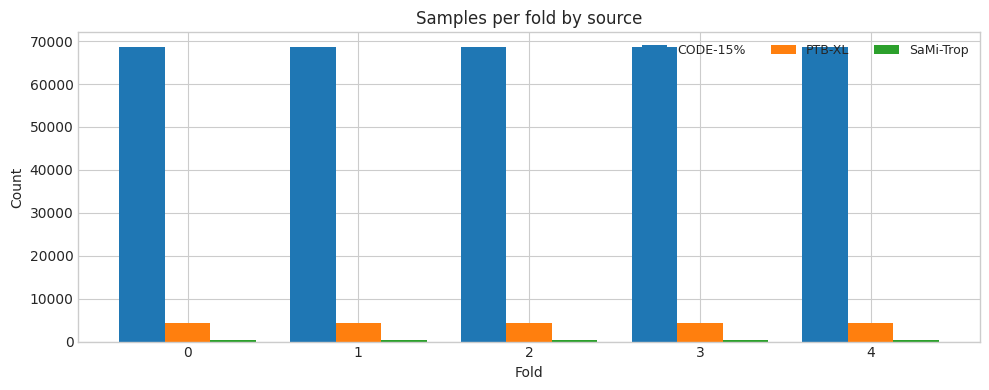

In [6]:
# Plot: samples per fold for each source
fold_order = sorted(df['fold'].dropna().unique())
src_order = sorted(df['source'].dropna().unique())

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

width = 0.8 / max(len(src_order), 1)
xs = np.arange(len(fold_order))

for i, s in enumerate(src_order):
    vals = (
        df[df.source == s].groupby('fold').size().reindex(fold_order, fill_value=0)
    )
    ax.bar(xs + (i - (len(src_order)-1)/2)*width, vals.values, width=width, label=s)

ax.set_title('Samples per fold by source')
ax.set_xlabel('Fold')
ax.set_ylabel('Count')
ax.set_xticks(xs)
ax.set_xticklabels([str(f) for f in fold_order])
ax.legend(ncols=3, fontsize=9)
plt.tight_layout()
plt.show()

## 3) Does each fold preserve age and sex?

We compare each fold to the overall distribution **within each source**, and also within each `(source, chagas)` stratum.

We use simple drift summaries:
- `age_mean` / `age_median` per fold vs overall
- `male_rate` per fold vs overall (excluding `Unknown`)

If you see big swings, it means stratification preserved labels/sources but not necessarily demographics.

In [7]:
# Helper: male rate excluding Unknown

def male_rate(series: pd.Series) -> float:
    s = series[series != 'Unknown']
    if len(s) == 0:
        return np.nan
    return (s == 'Male').mean()

# Overall per source (reference)
ref = (
    df.groupby('source')
      .agg(
          n=('exam_id', 'size'),
          age_mean=('age', 'mean'),
          age_median=('age', 'median'),
          male_rate=('sex_norm', male_rate),
      )
)

display(ref)

# Per fold per source
per_fold = (
    df.groupby(['source', 'fold'])
      .agg(
          n=('exam_id', 'size'),
          age_mean=('age', 'mean'),
          age_median=('age', 'median'),
          male_rate=('sex_norm', male_rate),
      )
      .reset_index()
)

# Join to compute deltas vs reference
per_fold = per_fold.merge(ref.reset_index(), on='source', suffixes=('', '_ref'))
per_fold['age_mean_delta'] = per_fold['age_mean'] - per_fold['age_mean_ref']
per_fold['age_median_delta'] = per_fold['age_median'] - per_fold['age_median_ref']
per_fold['male_rate_delta'] = per_fold['male_rate'] - per_fold['male_rate_ref']

display(per_fold.sort_values(['source', 'fold']))

# Summary of absolute drift per source
summary = (
    per_fold.groupby('source')
      .agg(
          max_abs_age_mean_delta=('age_mean_delta', lambda s: np.nanmax(np.abs(s))),
          max_abs_age_median_delta=('age_median_delta', lambda s: np.nanmax(np.abs(s))),
          max_abs_male_rate_delta=('male_rate_delta', lambda s: np.nanmax(np.abs(s))),
      )
)

display(summary)

,n,age_mean,age_median,male_rate
source,,,,
CODE-15%,342755,53.187869,54.0,0.403052
PTB-XL,21799,59.946695,62.0,0.520850
SaMi-Trop,1631,59.397302,59.0,0.327406


,source,fold,n,age_mean,age_median,male_rate,n_ref,age_mean_ref,age_median_ref,male_rate_ref,age_mean_delta,age_median_delta,male_rate_delta
0,CODE-15%,0,68521,53.285547,55.0,0.402811,342755,53.187869,54.0,0.403052,0.097679,1.0,-0.000241
1,CODE-15%,1,68607,53.197764,54.0,0.402976,342755,53.187869,54.0,0.403052,0.009895,0.0,-0.000075
2,CODE-15%,2,68505,53.122020,54.0,0.401314,342755,53.187869,54.0,0.403052,-0.065849,0.0,-0.001738
3,CODE-15%,3,68530,53.067547,54.0,0.405443,342755,53.187869,54.0,0.403052,-0.120322,0.0,0.002391
4,CODE-15%,4,68592,53.266372,54.0,0.402715,342755,53.187869,54.0,0.403052,0.078503,0.0,-0.000337
5,PTB-XL,0,4371,59.782201,61.0,0.527568,21799,59.946695,62.0,0.520850,-0.164494,-1.0,0.006718
6,PTB-XL,1,4289,60.103054,62.0,0.520634,21799,59.946695,62.0,0.520850,0.156360,0.0,-0.000215
7,PTB-XL,2,4393,59.614387,61.0,0.521056,21799,59.946695,62.0,0.520850,-0.332308,-1.0,0.000207
8,PTB-XL,3,4414,59.672859,61.0,0.527866,21799,59.946695,62.0,0.520850,-0.273836,-1.0,0.007016
9,PTB-XL,4,4332,60.573869,63.0,0.506925,21799,59.946695,62.0,0.520850,0.627174,1.0,-0.013924


,max_abs_age_mean_delta,max_abs_age_median_delta,max_abs_male_rate_delta
source,,,
CODE-15%,0.120322,1.0,0.002391
PTB-XL,0.627174,1.0,0.013924
SaMi-Trop,1.234983,1.0,0.037551


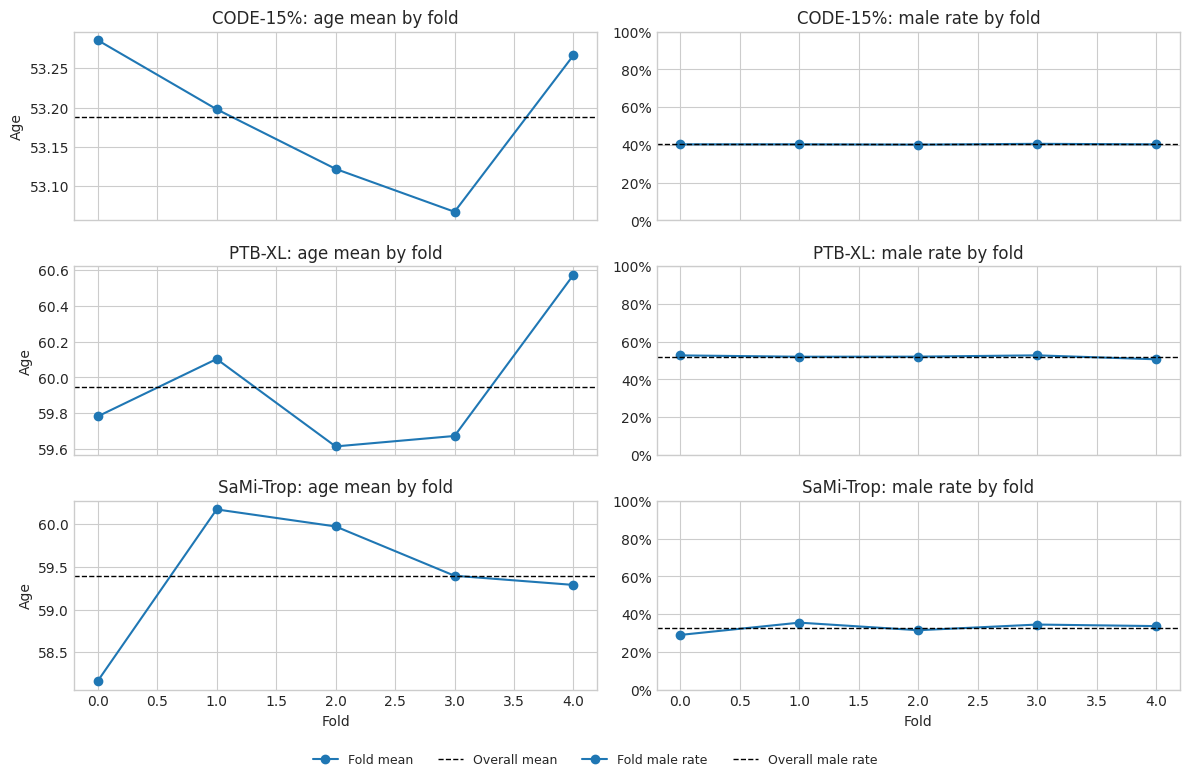

In [8]:
# Plot: age mean per fold with overall reference, per source
src_order = sorted(df['source'].dropna().unique())
fold_order = sorted(df['fold'].dropna().unique())

n_src = len(src_order)
fig, axes = plt.subplots(n_src, 2, figsize=(12, max(3, 2.6*n_src)), sharex=True)
if n_src == 1:
    axes = np.array([axes])

for r, src in enumerate(src_order):
    sub = df[df.source == src]

    # Age mean per fold
    age_means = sub.groupby('fold')['age'].mean().reindex(fold_order)
    age_ref = sub['age'].mean()

    ax = axes[r, 0]
    ax.plot(fold_order, age_means.values, marker='o', label='Fold mean')
    ax.axhline(age_ref, color='black', linestyle='--', linewidth=1, label='Overall mean')
    ax.set_title(f'{src}: age mean by fold')
    ax.set_ylabel('Age')

    # Male rate per fold
    ax2 = axes[r, 1]
    def _mr(g):
        s = g[g != 'Unknown']
        return np.nan if len(s)==0 else (s=='Male').mean()

    male_rates = sub.groupby('fold')['sex_norm'].apply(_mr).reindex(fold_order)
    male_ref = _mr(sub['sex_norm'])

    ax2.plot(fold_order, male_rates.values, marker='o', color='tab:blue', label='Fold male rate')
    if not np.isnan(male_ref):
        ax2.axhline(male_ref, color='black', linestyle='--', linewidth=1, label='Overall male rate')
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.set_ylim(0, 1)
    ax2.set_title(f'{src}: male rate by fold')

for ax in axes[-1, :]:
    ax.set_xlabel('Fold')

# Only one shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
handles2, labels2 = axes[0, 1].get_legend_handles_labels()
fig.legend(handles + handles2, labels + labels2, loc='lower center', ncols=4, fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### Optional: demographic drift within each (source, chagas) stratum

Since folds are stratified on `(source, chagas)`, it can also be useful to check age/sex drift **within** those strata.
This matters most for datasets with both labels (typically CODE-15).

,source,chagas,fold,n,age_mean,male_rate
0,CODE-15%,0,0,67236,53.147793,0.403370
1,CODE-15%,0,1,67319,53.051724,0.403541
2,CODE-15%,0,2,67171,52.987227,0.402242
3,CODE-15%,0,3,67197,52.909535,0.406476
4,CODE-15%,0,4,67273,53.134289,0.403401
5,CODE-15%,1,0,1285,60.493385,0.373541
6,CODE-15%,1,1,1288,60.830745,0.373447
7,CODE-15%,1,2,1334,59.909295,0.354573
8,CODE-15%,1,3,1333,61.033008,0.353338
9,CODE-15%,1,4,1319,60.003033,0.367703


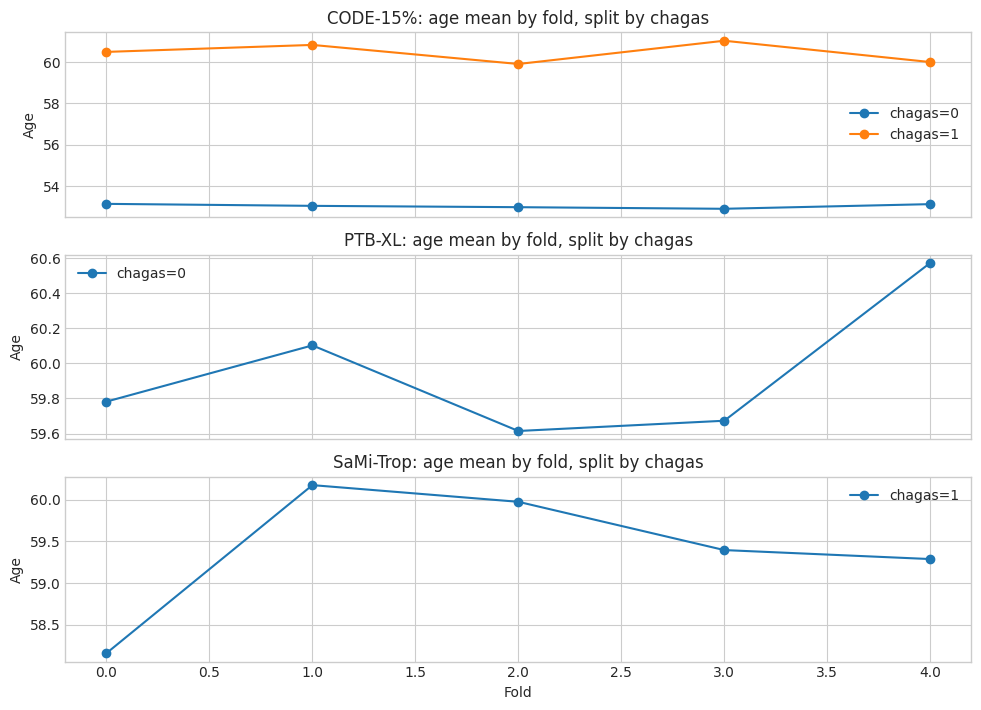

In [9]:
strata = (
    df.groupby(['source', 'chagas', 'fold'])
      .agg(
          n=('exam_id', 'size'),
          age_mean=('age', 'mean'),
          male_rate=('sex_norm', lambda s: (s[s!='Unknown']=='Male').mean() if (s!='Unknown').any() else np.nan),
      )
      .reset_index()
)

display(strata.sort_values(['source', 'chagas', 'fold']))

# Quick visualization: for each source, plot age mean per fold split by chagas
src_order = sorted(df['source'].dropna().unique())
fold_order = sorted(df['fold'].dropna().unique())

fig, axes = plt.subplots(len(src_order), 1, figsize=(10, max(3, 2.4*len(src_order))), sharex=True)
if len(src_order) == 1:
    axes = [axes]

for ax, src in zip(axes, src_order):
    sub = strata[strata.source == src]
    for ch in sorted(sub.chagas.dropna().unique()):
        sub2 = sub[sub.chagas == ch].set_index('fold').reindex(fold_order)
        ax.plot(fold_order, sub2['age_mean'].values, marker='o', label=f'chagas={ch}')
    ax.set_title(f'{src}: age mean by fold, split by chagas')
    ax.set_ylabel('Age')
    ax.legend()

axes[-1].set_xlabel('Fold')
plt.tight_layout()
plt.show()

## Interpretation guide

- If the **counts** and **label prevalence** are stable per fold within each source, then your intended stratification is working.
- If **age mean/median** or **male rate** shifts a lot between folds *within the same source (and optionally within the same label)*, then folds may be demographically imbalanced even if label/source are balanced.

Next steps (if you observe drift):
- Consider adding age-binning and/or sex into the stratification label, if that’s acceptable for your evaluation goals.
- Alternatively, keep current folds (label/source + patient-wise) and just **report** demographic differences.